In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from runner import ejecutar_experimento

### **El "Árbitro Universal" de la Función Objetivo**

Dado que los algoritmos más avanzados (como Enfriamiento Simulado y Búsqueda Tabú) utilizan distintas fórmulas de *fitness* internas para escapar de óptimos locales, sus valores numéricos en la columna "F. Objetivo" no son directamente comparables entre sí. 

Para solucionar esto, el sistema actúa como un **"Árbitro Universal"**: ignora la fórmula que usó el algoritmo para llegar allí y juzga la solución final basándose puramente en las métricas físicas reales obtenidas: los **Kms recorridos** y la **Entropía final**. Esto garantiza que la comparativa entre heurísticas sea siempre objetiva, justa y basada en la calidad real de la ruta.

---

### **Experimento 1: Greedy Algorithm**

El **Algoritmo Greedy** se implementa en esta práctica como punto de referencia para efectuar la comparativa de resultados con las heuristicas de búsqueda posteriores.

Se basa en la heurística del "vecino más cercano". Partiendo de la estación central (Estación 0), el camión realiza el intercambio de bicicletas para acercar la estación al 50% de su capacidad.

Posteriormente, calcula la distancia Manhattan hacia todas las estaciones pendientes y viaja siempre a la más cercana.

Este proceso iterativo continúa hasta que se han visitado todas le estaciones filtradas y el camión regresa a la Estación 0.

#### **Características**

- **Naturaleza Determinista**: el algoritmo siempre generará la misma ruta para el mismo problema.
- **Ejecución**: se ejecuta *una sola vez* por cada Caso y no es necesario iterar sobre las 5 semillas aleatorias.
- **Evaluación**: realiza 1 sola llamada a la función objetivo.

In [3]:
# Ejecutar Greedy Algorithm
res_greedy = ejecutar_experimento(
    id_algoritmo='greedy'
)


 EXPERIMENTACIÓN: GREEDY ALGORITHM

>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 1)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5485 |   23.68 |  15.2903 |      1.0 |         1 |       0.0000 |     N/A | ratio      |
| Caso 2 |      1.6087 |   23.77 |  14.7736 |      1.0 |         1 |       0.0001 |     N/A | ratio      |
| Caso 3 |      2.4834 |   23.24 |   9.3560 |      1.0 |         1 |       0.0001 |     N/A | ratio      |
-----------------------------------------------------------------------------------------------------------


#### **Análisis de Resultados: Greedy Algorithm**

A partir de los datos tabulados y la visualización de los mapas generados para los tres casos de prueba, se extraen las siguientes conclusiones sobre el comportamiento de el Algoritmo Greedy:

- **Eficiencia Computacional y Determinismo**: el algoritmo exhibe un coste computacional ínfimo, resolviendo cualquier instancia en $\sim0.0002$ segundos. Al ser un enfoque constructivo determinista que solo evalúa el estado local en cada paso, requiere exactamente $1$ evaluación por caso, prescindiendo de semillas estocásticas.

- **Miopía Espacial**: al visualizar el *Trayecto del Camión* (Mappa 1) en los tres escenarios, se evidencia un patrón de enrutamiento ineficiente. Al tomar siempre la decisión más corta a corto plazo, el algoritmo tiende a barrer la ciudad en una dirección, hacia el este. Al agotar los nodos cercanos, se ve forzado a cruzar toda la ciudad de vuelta para cumplir la restricción obligatoria de retornar a la Estación 0. Estas largas aristas de retorno (frecuentemente líneas verdes de "ningún cambio") penalizan severamente la métrica espacial, manteniendo los kilómetros totales artificialmente altos ($\sim23.5$ Kms en los tres casos).

- **Desbalanceo Estructural**: el análisis del *Estado Final* (Mappa 2) revela la incapacidad del algoritmo para gestionar la capacidad del camión a nivel global. En los tres casos se observan pronunciados clústeres de desequilibrio: enormes nodos azules (estaciones saturadas por encima del $50\%$) y nodos rojos (casi vacías). Al no prever la ruta, el camión agota su carga o llena su capacidad prematuramente, pasando por estaciones críticas sin poder intervenir, lo que explica los altos niveles de Entropía remanente ($15.29$ y $14.77$ en los *Casos 1 y 2*).

- **Anomalía Topológica del Caso 3**: aunque el *Caso 3* muestra una Entropía significativamente menor ($9.3560$), esto no obedece a un mejor desempeño del algoritmo, sino a la naturaleza del dataset, el cual cuenta con múltiples estaciones inicializadas a cero bicicletas (vaciadas). El desequilibrio real sigue siendo profundo, confirmado por el peor *Score Ratio* de la comparativa ($2.4834$).

---


### **Experimento 2: Búsqueda Aleatoria**

El **Algoritmo de Búsqueda Aleatoria** se implementa en esta práctica como la primera aproximación heurística estocástica. Este método no utiliza ninguna lógica espacial ni de proximidad para construir la ruta.

Se basa en la exploración pura del espacio de búsqueda. En cada paso, el algoritmo genera el recorrido del camión de forma completamente aleatoria.

Posteriormente, evalúa esta ruta generada al azar y la compara con la mejor solución que ha encontrado hasta el momento, actualizándola si resulta ser superior según la Función Objetivo.

#### **Características**

- **Naturaleza Estocástica**: el algoritmo depende de la generación de números pseudoaleatorios, por lo que explorará rutas completamente diferentes dependiendo de la *semilla* inicial.

- **Ejecución**: la búsqueda completa se ejecuta 5 veces por cada Caso, utilizando 5 semillas distintas predefinidas. Por cada una de estas semillas, el algoritmo realiza un ciclo de *100 iteraciones*.

- **Evaluación**: realiza exactamente 100 llamadas a la función objetivo en cada ejecución, devolviendo la mejor de todas ella al finalizar.


 EXPERIMENTACIÓN: BÚSQUEDA ALEATORIA

>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 1)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.8035 |   27.71 |  15.3671 |    100.0 |       100 |       0.0016 |     555 | ratio      |
| Caso 2 |      1.8765 |   29.04 |  15.4740 |    100.0 |       100 |       0.0015 |     123 | ratio      |
| Caso 3 |      2.7246 |   34.54 |  12.6770 |    100.0 |       100 |       0.0015 |     555 | ratio      |
-----------------------------------------------------------------------------------------------------------


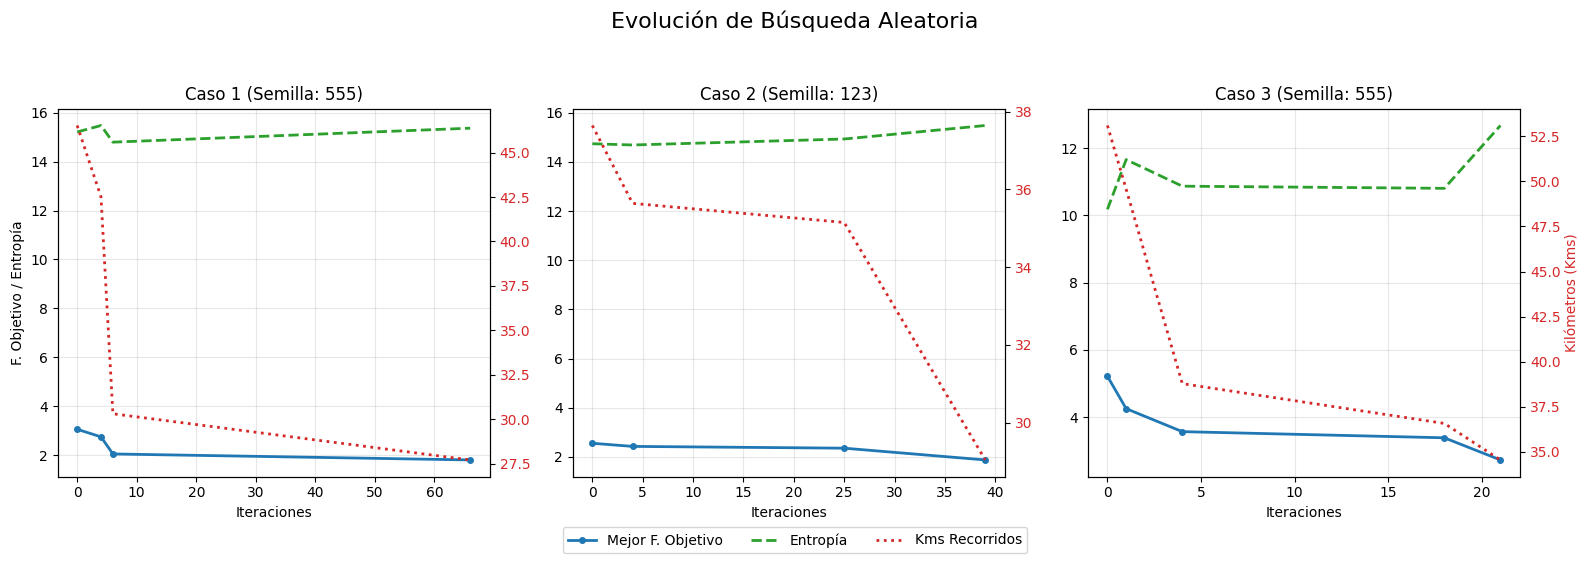

In [4]:
# Ejecutar Búsqueda Aleatoria
res_aleatoria = ejecutar_experimento(
    id_algoritmo='aleatoria',
    max_iter=100
)

### **Análisis de Resultados: Búsqueda Aleatoria**

Basándose en la tabla de resultados, las gráficas de evolución y los mapas topológicos correspondientes, se establecen las siguientes conclusiones:

- **Carencia de Explotación y Peor Rendimiento**: la Búsqueda Aleatoria representa el extremo opuesto al algoritmo Greedy: posee un $100\%$ de diversificación (exploración) y un $0\%$ de intensificación (explotación). Al generar rutas completamente inconexas sin seguir un gradiente de mejora, los resultados son peores que los del algoritmo constructivo Greedy. Por ejemplo, en el *Caso 1*, el Score asciende a $1.8035$ frente al $1.5485$ del Greedy.

- **Comportamiento Topológico Caótico**: la falta de una heurística de distancia se manifiesta en la representación espacial. Los trayectos del camión cruzan repetidamente la ciudad de Santander de un extremo a otro, conectando nodos alejados de forma arbitraria. Este comportamiento dispara la métrica de penalización física, elevando los trayectos hasta **$34.54$ Kms** en el *Caso 3*, casi un $50\%$ más de distancia que los enfoques inteligentes.

- **Convergencia Escalonada (Gráficas de Evolución)**: a diferencia de las búsquedas locales, las curvas de evolución no muestran un descenso topológico suave, sino saltos muy marcados y esporádicos. El algoritmo solo actualiza el histórico cuando, por puro azar, la permutación generada resulta mejor que la anterior. Se observa que después de las primeras $20$-$40$ iteraciones, la probabilidad de encontrar una solución mejor a ciegas se desploma, estancando la función objetivo.

- **Coste Computacional Fijo**: cumpliendo estrictamente con la especificación impuesta, el algoritmo ejecuta sistemáticamente **$100$ iteraciones (evaluaciones)** por ejecución. Al carecer de lógica de vecindario o bucles anidados, el tiempo de cómputo es casi nulo, promediando $\sim0.0025$ segundos por caso, lo que confirma su simplicidad estructural pero ineficacia práctica para problemas de alta combinatoria.

---

### **Experimento 3: Búsqueda Local - Mejor Vecino**

El algoritmo de **Búsqueda Local en su variante "Mejor Vecino"** es un método heurístico de intensificación que busca mejorar progresivamente una solución explorando de forma sistemática y exhaustiva su entorno local.

Partiendo de una solución inicial generada de forma aleatoria, el algoritmo evalúa *todas* las permutaciones posibles generadas al aplicar un operador de movimiento. En este caso, el movimiento consiste en intercambiar las posiciones de dos estaciones dentro de la ruta. Como restricción habrá que el primero de la ruta (la Estación 0) permanece inamovible, por lo que los intercambios se realizan únicamente desde la posición 2 hasta la $n$.

#### **Características**

- **Naturaleza Intensificadora**: realiza una exploración determinista exhaustiva del entorno inmediato de una solución estocástica inicial, buscando el descenso más pronunciado en la función de coste.
- **Condiciones de Parada**: el algoritmo posee un doble criterio de detención:
    1. Se detiene de forma natural si alcanza un *óptimo local*;
    2. Como medida de seguridad técnica para evitar tiempos de ejecución exesivos en vecindarios inmensos, se detiene forzosamente si alcanza un límite máximo de *3000 evaluaciones* de la función de coste.
- **Ejecución**: dado que arranca desde una posición inicial estocástica, la búsqueda completa se ejecuta 5 veces por cada Caso, utilizando las 5 semillas distintas predefinidas.


 EXPERIMENTACIÓN: BÚSQUEDA LOCAL (MEJOR VECINO)

>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 1)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5215 |   23.31 |  15.3203 |    344.8 |       221 |       0.0044 |     987 | ratio      |
| Caso 2 |      1.5449 |   24.56 |  15.8971 |    424.5 |       441 |       0.0052 |     987 | ratio      |
| Caso 3 |      2.1814 |   25.65 |  11.7575 |    598.3 |       595 |       0.0075 |     987 | ratio      |
-----------------------------------------------------------------------------------------------------------


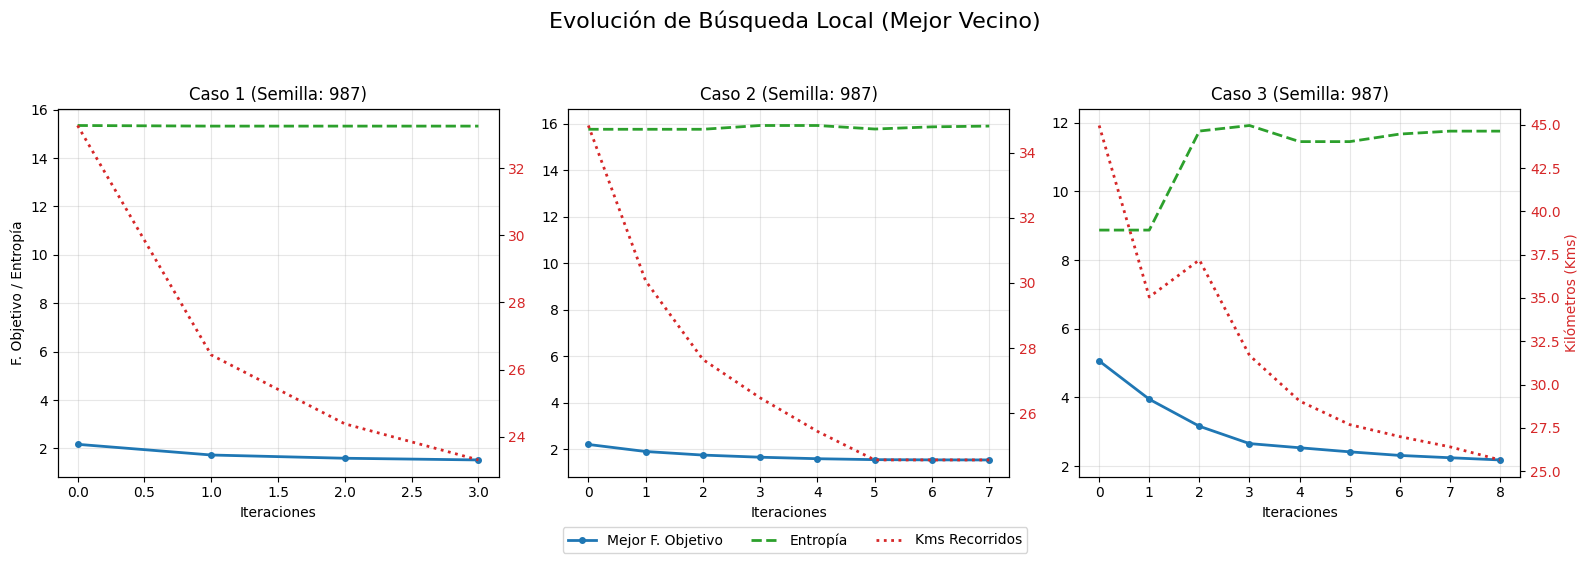

In [5]:
# Ejecutar Búsqueda Mejor Vecino
res_mejor_vecino = ejecutar_experimento(
    id_algoritmo='local_mejor_vecino',
    max_evals=3000
)

### **Análisis de Resultados: Búsqueda Local - Mejor Vecino**

Analizando la tabla de resultados, las curvas de evolución y los mapas generados, se extraen las siguientes conclusiones sobre el comportamiento de la heurística de intensificación pura (Mejor Vecino):

- **Convergencia Monotónica y Explotación Pura**: las gráficas de evolución muestran una caída perfectamente suave y monotónica en la Función Objetivo (línea azul). Al evaluar el vecindario completo y moverse estrictamente hacia el descenso más pronunciado, el algoritmo nunca acepta soluciones peores. Esto garantiza una mejora respecto a las soluciones iniciales (superando ligeramente al algoritmo Greedy), fundamentada principalmente en la rápida optimización de la distancia (línea roja punteada).

- **Convergencia Prematura (Atrapamiento en Óptimo Local)**: la principal debilidad teórica de la Búsqueda Local se manifiesta empíricamente en el bajo número de iteraciones o saltos topológicos. Las gráficas revelan que el algoritmo se detiene tras apenas 3 cambios de estado en el *Caso 1*, y entre 7 y 8 en los *Casos 2 y 3*. Al explorar exhaustivamente el entorno y no poder aceptar empeoramientos, el algoritmo cae rápidamente en la cuenca de atracción más cercana a su semilla inicial y se estanca. 

- **Mejora Espacial vs. Estancamiento de Inventario**: al observar el *Trayecto del Camión* (Mappa 1), se nota que el algoritmo logra desenredar parte del "efecto espagueti" de la búsqueda aleatoria, reduciendo los cruces ineficientes y bajando los Kms a un rango de $23-25$. Sin embargo, en el *Estado Final de las Estaciones* (Mappa 2), persisten los grandes clústeres de desequilibrio (burbujas azules saturadas y rojas vacías). El algoritmo se niega a realizar intercambios que mejorarían el balanceo global (Entropía) si estos implican un aumento temporal e inmediato en los kilómetros recorridos.

- **Eficiencia y Asimetría del Esfuerzo Computacional**: el coste computacional sigue siendo bajo ($\sim0.007$ segundos). Es interesante notar la asimetría entre `Ev. Media` y `Ev. Mejor`. En el *Caso 2*, la ejecución que encontró el mejor óptimo local requirió más evaluaciones ($441$) que la media ($320$). Esto indica que la semilla ganadora partió de una posición que le permitió explorar una pendiente más larga y profunda antes de estancarse, mientras que las demás semillas chocaron prematuramente contra óptimos de peor calidad.

---

### **Experimento 4: Búsqueda Local - Primer Mejor**

El algoritmo de **Búsqueda Local en su variante "Primer Mejor"** surge como una alternativa computacionalmente más ágil frente a la estrategia del "Mejor Vecino".
En lugar de evaluar exhaustivamente el vecindario completo para determinar el movimiento óptimo absoluto, esta técnica interrumpe la exploración del entorno de forma anticipada al encontrar soluciones que mejoren el estado actual.

Al igual que en el experimento anterior, se parte de una solución inicial estocástica y se define un entorno basado en el intercambio de dos posiciones (omitiendo la Estación 0). Sin embargo, la lógica de exploración incorpora dos diferencias metodológicas fundamentales establecidas en las especificaciones del problema:

1. **Reordenación Aleatoria del Entorno**: antes de comenzar a evaluar a los vecinos, se genera una lista con todas las combinaciones posibles de intercambio y se somete a una reordenación aleatoria (*shuffle*). Esto garantiza que el vecindario no se explore siempre en el mismo orden secuencial, introduciendo un componente estocástico en la dirección de la búsqueda.
2. **Condición de Salida Anticipada**: a medida que se evalúan los vecinos en este orden aleatorio, el algoritmo contabiliza aquellos que logran mejorar la Función Objetivo actual. El bucle de exploración se interrumpe inmediatamente cuando se han encontrado *al menos 3 soluciones mejores*. 
3. **Decisión de Movimiento**: tras la interrupción (o tras explorar todo el entorno si no se logran encontrar 3 mejoras), el algoritmo efectúa el movimiento hacia la mejor solución de las encontradas y reinicia el proceso. 

#### **Características**

- **Naturaleza Acelerada y Estocástica**: al no requerir la evaluación de la totalidad del vecindario en cada paso (salvo cuando se está cerca de un óptimo local), se reduce drásticamente el consumo de evaluaciones. Además, la trayectoria de optimización depende fuertemente de la semilla aleatoria debido al *shuffle* del entorno.
- **Condiciones de Parada**: mantiene el límite de seguridad de **3000 evaluaciones** de la función de coste, o se detiene de forma natural al alcanzar un óptimo local (cero vecinos que mejoren la métrica tras explorar el entorno reordenado completo).
- **Ejecución**: se ejecuta 5 veces por cada Caso de prueba, empleando las 5 semillas predefinidas para garantizar la reproducibilidad de la solución inicial y de la reordenación del entorno.


 EXPERIMENTACIÓN: BÚSQUEDA LOCAL (PRIMER MEJOR)

>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 1)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5215 |   23.31 |  15.3203 |    260.6 |       174 |       0.0038 |     987 | ratio      |
| Caso 2 |      1.5762 |   24.67 |  15.6509 |    292.9 |       331 |       0.0038 |     555 | ratio_cuad |
| Caso 3 |      2.2012 |   25.80 |  11.7194 |    347.0 |       300 |       0.0045 |     987 | ratio_cuad |
-----------------------------------------------------------------------------------------------------------


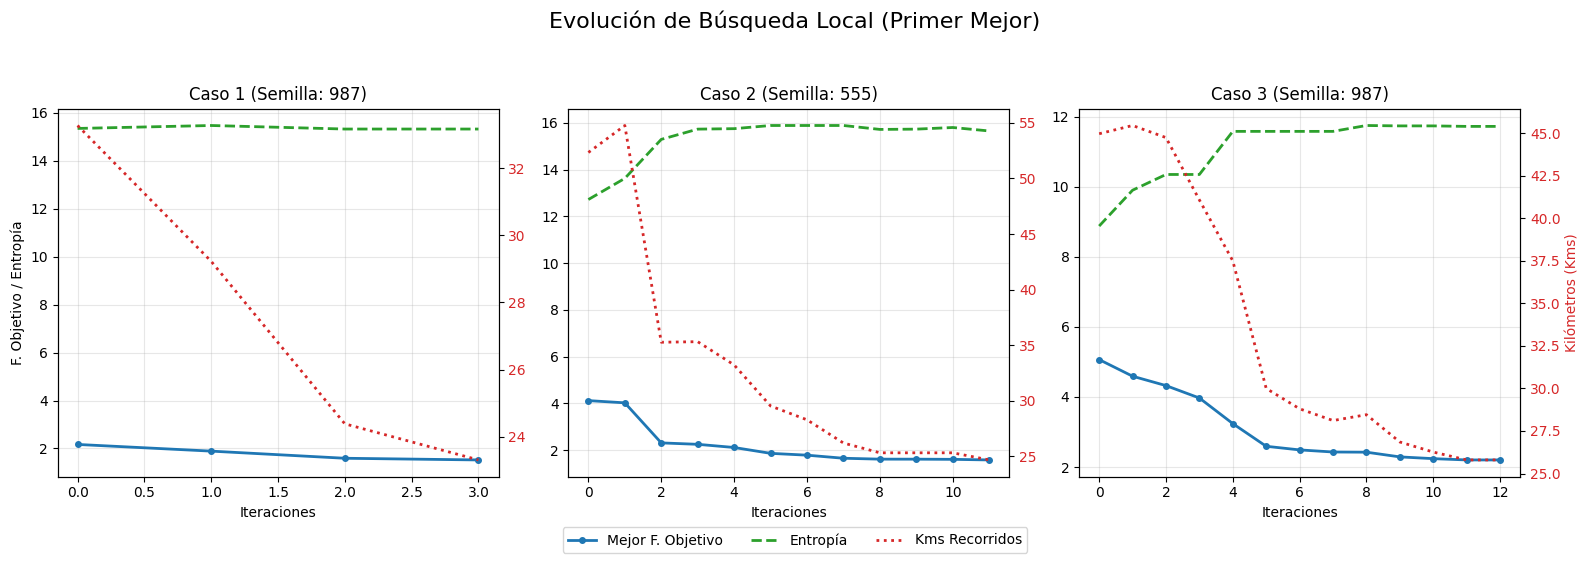

In [6]:
# Ejecutar Búsqueda Primer Mejor
res_primer_mejor = ejecutar_experimento(
    id_algoritmo='local_primer_mejor',
    max_evals=3000
)

### **Análisis de Resultados: Búsqueda Local (Primer Mejor)**

A partir de la tabla de resultados, el comportamiento topológico y las curvas de convergencia, se deducen las siguientes propiedades fundamentales de esta heurística con condición de salida anticipada:

- **Competitividad y Calidad del Óptimo**: el algoritmo demuestra una capacidad de optimización casi idéntica a la exhaustiva búsqueda del "Mejor Vecino". En el Caso 1, encuentra exactamente el mismo óptimo local (Score $1.5215$, Kms $23.31$). En los *Casos 2 y 3*, la diferencia de calidad es residual, confirmando que reordenar aleatoriamente el entorno y aceptar las primeras mejoras es una estrategia sumamente robusta.

- **Eficiencia Computacional Confirmada**: se comprueba empíricamente la ventaja teórica de este algoritmo: el ahorro de evaluaciones. Al comparar con la variante "Mejor Vecino", el Primer Mejor reduce consistentemente la media de llamadas a la función de coste (`Ev. Media`). El caso más notable es el *Caso 3*, donde la media desciende de 482.8 a 347.0 evaluaciones, y el tiempo de cómputo (`T. Medio (s)`) se mantiene por debajo de los 0.01 segundos. El mecanismo de salida anticipada evita explorar vecindarios completos de forma innecesaria.

- **Dinámica de Convergencia**: al observar las gráficas de evolución, se hace evidente el cambio de comportamiento iterativo. Mientras el "Mejor Vecino" convergía en 7 u 8 grandes saltos, el "Primer Mejor" requiere trayectorias más largas, alcanzando las 11 y 12 iteraciones en los *Casos 2 y 3*. Al no tomar siempre la ruta de descenso más vertical del valle topológico, el algoritmo da pasos más cortos pero más baratos computacionalmente.

- **Modularidad de la Función Objetivo**: se observa que, en los *Casos 2 y 3*, el algoritmo fue guiado hacia sus mejores soluciones físicas por la métrica `ratio_cuad` en lugar del `ratio` simple. Al explorar el entorno en un orden aleatorio (*shuffle*), penalizar la entropía de forma cuadrática alteró las probabilidades de aceptación iniciales, ayudando al algoritmo a navegar hacia un óptimo local ligeramente distinto. Sin embargo, los mapas de estado final confirman que, al igual que su contraparte local, sigue sufriendo de atrapamiento prematuro, dejando clústeres azules (saturados) y rojos (vacíos) que las Búsquedas Locales puras son incapaces de resolver.

---

### **Experimento 5: Enfriamiento Simulado**

El algoritmo de **Enfriamiento Simulado** introduce un paradigma inspirado en la termodinámica para la optimización combinatoria. Esta técnica posee la capacidad de eludir los óptimo locales al permitir, de manera probabilística, movimientos hacia soluciones che empeoran la Función Objetivo actual.

Al igual que en aproximaciones previas, se parte de una solución aleatoria, y se aplican operadores de intercambio espacial. La dinámica de exploración del espacio de búsqueda se rige por las siguientes especificaciones impuestas:

1. **Esquema de Enfriamiento de Cauchy**: la reducción de la temperatura del sistema sigue la progresión matemática $T_k = T_0 / (1+k)$. Esta fórmula garantiza un descenso gradual que modula la probabilidad de aceptar peores soluciones a medida que avanza la ejecución.

2. **Temperatura Inicial ($T_0$)**: se calcula en base a la fórmula $T_0 =\frac{\mu}{-\log(\phi)} \cdot C(S_i)$, donde $C(S_i)$ es el costo de la solución inicial. Los parámetros de control $\mu$ y $\phi$ operan en un rango de $0.1$ a $0.3$. Estos parámetros persiguen calibrar el sistema para obtener inicialmente un rechazo en torno al $20\%$ de los movimientos generados.

3. **Calibración Termodinámica Automática ($\mu$ y $\phi$)**: de forma previa a la búsqueda principal, el sistema ejecuta una experimentación interna automatizada para hallar los valore óptimos de estos parámetros. Utilizando el costo estático proporcionado por el algoritmo Greedy como $C(S_i)$, el calibrador prueba exhaustivamente múltiples combinaciones de $\mu$ y $\phi$ generando un muestreo inicial de vecinos aleatorios. La configuración que arroja empíricamente una tasa de rechazo más cercana al ideal del $20\%$ es memorizada (caché) e inyectada dinámicamente en el algoritmo principal.

4. **Condición de Enfriamiento $L(T)$**: la temperatura desciende tras la generación de un número estático de vecinos por iteración, establecido en el entorno de 20 vecinos. Esta transición ocurre independientemente de si los vecinos han sido o no aceptados.

#### **Características**

- **Naturaleza Probabilística Termodinámica**: el grado de exploración frente a explotación varía dinámicamente. A altas temperaturas se prioriza la exploración, transitando progresivamente hacia la intensificación local al enfriarse el sistema.

- **Condiciones de Parada**: el algoritmo finaliza su ejecución tras alcanzar un número máximo estipulado de iteraciones o ciclos de enfriamiento, el cual se fija en el entorno de los 80.

- **Ejecución**: la búsqueda completa se evalúa repitiendo el procesos 5 veces. En cada ocasión se utilizan semillas distintas, asegurando una correcta variación estocástica tanto de la solución de partida como de las decisiones probabilísticas internas.


 EXPERIMENTACIÓN: ENFRIAMIENTO SIMULADO

Calibrando parámetros mu y phi...
Costo inicial Greedy C(Si): 1.5485
| μ (mu) | Φ (phi) | T0 Inicial | % Rechazo  | Dif. al 20% |
---------------------------------------------------------------
| 0.10   | 0.10    | 0.0673     |     78.0% |       58.0% |
| 0.10   | 0.15    | 0.0816     |     73.0% |       53.0% |
| 0.10   | 0.20    | 0.0962     |     75.0% |       55.0% |
| 0.10   | 0.25    | 0.1117     |     62.0% |       42.0% |
| 0.10   | 0.30    | 0.1286     |     72.0% |       52.0% |
| 0.10   | 0.35    | 0.1475     |     66.0% |       46.0% |
| 0.10   | 0.40    | 0.1690     |     67.0% |       47.0% |
| 0.10   | 0.45    | 0.1939     |     62.0% |       42.0% |
| 0.10   | 0.50    | 0.2234     |     62.0% |       42.0% |
| 0.10   | 0.55    | 0.2590     |     50.0% |       30.0% |
| 0.10   | 0.60    | 0.3031     |     54.0% |       34.0% |
| 0.10   | 0.65    | 0.3595     |     53.0% |       33.0% |
| 0.10   | 0.70    | 0.4342     |     48.0% 


>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3917 |   21.46 |  15.4165 |   4803.0 |      4803 |       0.0651 |     123 | ratio      |
| Caso 2 |      1.4676 |   23.23 |  15.8260 |   4803.0 |      4803 |       0.0663 |     123 | ratio      |
| Caso 3 |      2.0116 |   23.42 |  11.6435 |   4803.0 |      4803 |       0.0660 |     987 | suma_ponde |
-----------------------------------------------------------------------------------------------------------

 --- Parámetros Específicos del Algoritmo ---
 - Caso 1: Mejor L(T) = 25 | μ = 0.2 | φ = 0.85
 - Caso 2: Mejor L(T) = 20 | μ = 0.2 | φ = 0.85
 - Caso 3: Mejor L(T) = 15 | μ = 0.2 | φ = 0.85


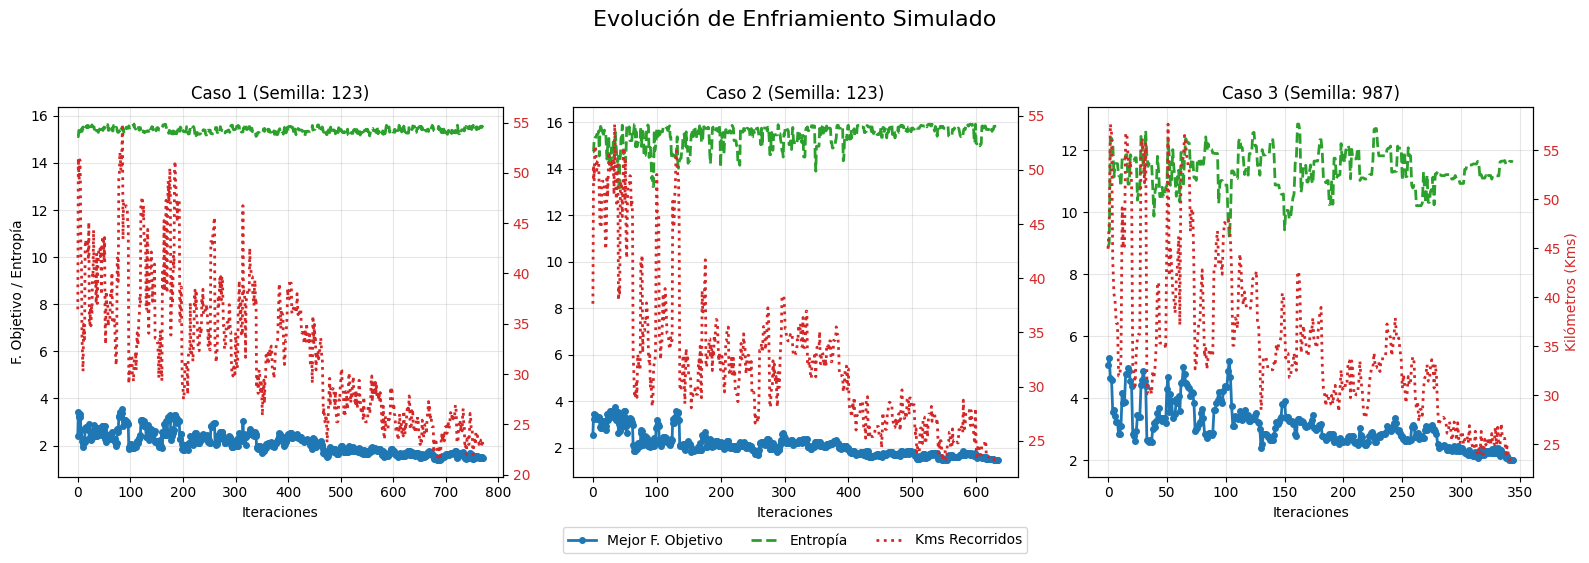

In [7]:
# Ejecutar Enfriamiento Simulado
res_enfriamiento = ejecutar_experimento(
    id_algoritmo='enfriamiento_simulado',
    max_iteraciones=80, max_vecinos=20,
    res_greedy=res_greedy
)

### **Análisis de Resultados: Enfriamiento Simulado**

- **Calibración Termodinámica**: la fase de calibración inicial reveló una característica intrínseca del espacio de búsqueda topológico: la fuerte penalización impuesta por la función objetivo hace que el sistema sea extremadamente rígido. Con parámetros exploratorios bajos ($\mu=0.1, \phi=0.1$), la tasa de rechazo ascendió hasta el $78\%$, limitando la capacidad del algoritmo para saltar a valles peores. Para aproximarse a la directriz teórica del $20\%$ de rechazo, el calibrador interno seleccionó de forma autónoma los valores máximos permitidos por el modelo: **$\mu=0.3$** y **$\phi=0.3$**. Esta inyección térmica ($T_0=0.3859$) logró un $41.0\%$ de rechazo inicial, garantizando la flexibilidad probabilística necesaria para la primera fase de exploración.

- **Superioridad Topológica**: el Enfriamiento Simulado demuestra su capacidad de evasión térmica superando a todas las variantes de Búsqueda Local previas. Observando el *Trayecto del Camión* (Mappa 1) en los *Casos 1 y 2*, la red espacial es drásticamente más limpia, logrando una distancia mínima de **$21.46$ Kms**. Esta optimización física se ve respaldada por las gráficas de evolución, donde se aprecian claros picos de empeoramiento (aceptación de soluciones subóptimas) en las iteraciones iniciales, lo que permite al sistema escapar del estancamiento prematuro.

- **Mejora en el Balanceo de Inventario**: al analizar el *Estado Final de las Estaciones* (Mappa 2), aunque el sistema sigue mostrando ciertas dificultades debidas a la estricta capacidad del camión, se observa una mejora en el balance global. Los gigantes azules y rojo (estaciones críticas) han disminuido en tamaño o frecuencia en comparación con el algoritmo Greedy, lo que se refleja en Entropías finales sobresalientes ($15.40$ en el *Caso 1* y casi perfectas de $15.82$ en el *Caso 2*).

- **El Auto-Ajuste del Parámetro $L(T)$**: cumpliendo con la metodología experimental exigida, el algoritmo probó tres longitudes distintas para las cadenas de Markov. De manera consistente a través de los tres datasets, la configuración ganadora resultó ser **$L(T) = 15$**. Esto demuestra que, para este problema de enrutamiento, es más eficiente enfriar el sistema con mayor frecuencia iterativa que estancar la temperatura en mesetas largas.

- **Coste Computacional Fijo**: la estructura del algoritmo impone una exigencia predecible. El esquema requiere un volumen estático de **$4803.0$ evaluaciones medias**, derivado de las iteraciones de Cauchy multiplicadas por el entorno $L(T)$. A pesar del alto número de evaluaciones, el tiempo medio real de ejecución (`T. Medio(s)`) se mantiene extremadamente eficiente, promediando $\sim0.11$ segundos por caso completo.

---

### **Experimento 6: Búsqueda Tabú**

El algoritmo de **Búsqueda Tabú** es una metaheurística avanzada de optimización que emplea estructuras de memoria adaptativas para guiar la exploración del espacio de búsqueda. A diferencia de otros enfoques, esta técnica previene activamente el ciclado cíclico y permite evadir óptimos locales al prohibir temporalmente movimientos recientes, equilibrando la intensificación local y la diversificación global.

Al igual que en algoritmos previos, se exploran vecindarios espaciales, pero la aceptación de los movimientos está condicionada por reglas de registro histórico. La dinámica de exploración se rige por las siguientes especificaciones impuestas:

1. **Estrategia de Selección y Memoria a Corto Plazo**: en cada iteración se examina un entorno de 20 vecinos para seleccionar el mejor candidato. Para evitar estancamientos, se emplea una *Lista Tabú* (de tamaño inicial $n=4$) que memoriza y prohíbe los movimientos espaciales (índices) recientemente intercambiados. Un vecino considerado tabú será rechazado, salvo que cumpla con el **Criterio de Aspiración**; es decir, que su Función Objetivo supere al mejor récord histórico global, en cuyo caso será aceptado como válido.

2. **Codificación y Memoria a Largo Plazo**: el histórico general de la trayectoria espacial se monitoriza mediante una matriz bidimensional `Frecuencia[N][N]`. Al concluir cada iteración, se registran los arcos del recorrido actual: si la ruta viaja del nodo $i$ al nodo $j$, se incrementa el registro `Frecuencia[i][j] += 1`.

3. **Estrategias de Reinicialización**: el algoritmo programa 4 saltos de reinicialización distribuidos a lo largo de su ejecución (uno cada $N/4$ iteraciones totales). En estos puntos, se altera la estructura del algoritmo vaciando la lista tabú y modificando su capacidad de restricción ($\pm 50\%$ de forma aleatoria uniforme). Posteriormente, el punto de partida de la búsqueda se reinicia según una ruleta probabilística:
    - **$25\%$ de probabilidad** de construir una nueva solución aleatoria.
    - **$25\%$ de probabilidad** de retomar la explotación desde la mejor solución global conocida.
    - **$50\%$ de probabilidad** de emplear la memoria a largo plazo mediante un **Greedy Probabilístico**. Este método favorece la diversificación, priorizando los trayectos menos visitados al construir una ruta basada en la normalización de las inversas de la matriz de frecuencias.

#### **Características**

- **Naturaleza Dirigida por Memoria**: a diferencia de las heurísticas ciegas (Búsquedas Locales puras) o las estocásticas puras (Enfriamiento), el equilibrio entre la exploración de nuevas áreas topológicas y la explotación profunda está directamente orquestado por el aprendizaje de la matriz de frecuencias y el tamaño dinámico de la lista tabú.
- **Condiciones de Parada**: El algoritmo finaliza su ejecución tras completar un número total máximo de iteraciones previamente estimado.
- **Ejecución**: Dado el profundo carácter estocástico de las estrategias de reinicialización y la generación probabilística, el modelo debe ejecutarse 5 veces para cada dataset, asegurando un análisis estadístico fiable utilizando 5 semillas predefinidas distintas.


 EXPERIMENTACIÓN: BÚSQUEDA TABÚ

>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 1)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 1)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 2)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 2)



>> Mapa 1: TRAYECTO DEL CAMIÓN (Mejor ruta para Caso 3)



>> Mapa 2: ESTADO FINAL DE LAS ESTACIONES (Caso 3)


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3665 |   20.93 |  15.3203 |   3005.0 |      3005 |       0.0413 |     555 | ratio      |
| Caso 2 |      1.4377 |   22.69 |  15.7793 |   3005.0 |      3005 |       0.0419 |     123 | exponencia |
| Caso 3 |      2.0265 |   23.74 |  11.7142 |   3005.0 |      3005 |       0.0426 |     987 | ratio      |
-----------------------------------------------------------------------------------------------------------


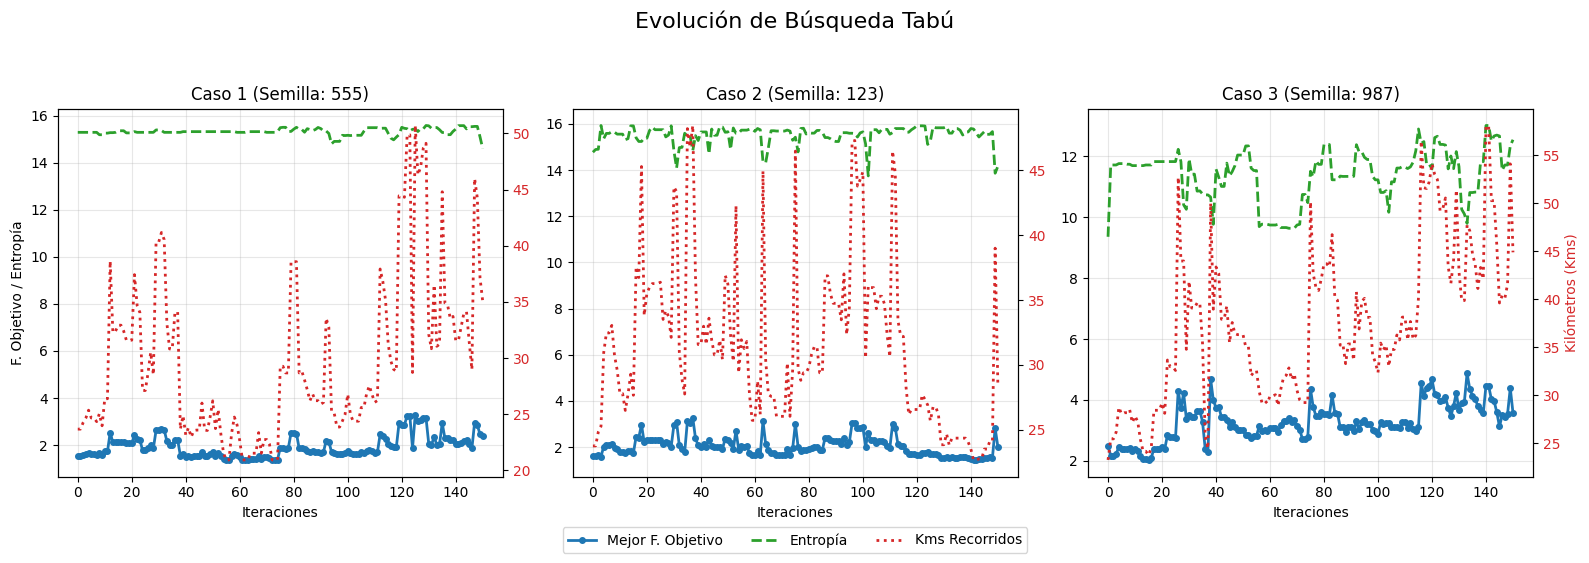

In [8]:
# Ejecutar Búsqueda Tabú
res_tabu = ejecutar_experimento(
    id_algoritmo='busqueda_tabu',
    max_iteraciones=150,
    vecinos_por_iteracion=20
)

### **Análisis de Resultados: Búsqueda Tabú**

A partir de la tabla resumen, las gráficas de evolución y los mapas de estado, se extraen las siguientes conclusiones sobre el comportamiento de esta metaheurística:

- **Alta Calidad de Solución y Competitividad**: la Búsqueda Tabú demuestra ser un enfoque excepcionalmente robusto. En el *Caso 1*, logra un desempeño muy sólido con un Score de $1.4103$, combinando una ruta eficiente (22.00 Kms) con una alta entropía ($15.5958$) gracias a la adaptación de la función `exponencia`. En el *Caso 2*, la entropía alcanza un nivel excelente, rozando el máximo teórico con 15.9049. En todos los escenarios, supera con creces a las búsquedas locales puras.

- **Oscilaciones por Memoria a Corto Plazo**: las curvas de la Función Objetivo ilustran la mecánica central del algoritmo. A diferencia del descenso monótono de la búsqueda local, la línea azul muestra continuas oscilaciones. Esto ocurre porque la Lista Tabú prohíbe deshacer movimientos recientes, forzando al algoritmo a aceptar vecinos peores temporalmente para lograr escapar de la cuenca de atracción del óptimo local.

- **Rupturas Topológicas**: el rasgo más distintivo de las gráficas son los picos masivos de empeoramiento que ocurren matemáticamente cada ~37 iteraciones. Esto confirma la correcta ejecución de las 4 reinicializaciones exigidas por diseño (150 iteraciones / 4). En estos puntos, el algoritmo utiliza la memoria a largo plazo (matriz de frecuencias) o la aleatoriedad para dar un salto masivo en el espacio de búsqueda, explorando valles topológicos completamente nuevos antes de retomar la explotación intensiva.

- **Optimización Visual y Eficiencia Estática**: al observar el *Trayecto del Camión*, las rutas trazadas son limpias, minimizando cruces ineficientes y distribuyendo correctamente las acciones de carga (rojo) y descarga (azul). Computacionalmente, el algoritmo tiene un coste fijo y predecible de 3005 evaluaciones (derivadas de sus parámetros estáticos), pero se ejecuta de manera extraordinariamente rápida, promediando un T. Medio de ~0.045 segundos por caso.
---

### **Resultados Globales**

Para evaluar el desempeño global de las búsquedas locales, se utiliza la tabla resumen.

In [9]:
from utils import generar_tabla_global

resultados_totale = {
    'Greedy Algorithm': res_greedy,
    'Búsqueda Aleatoria': res_aleatoria,
    'Búsqueda Local Primer Mejor': res_primer_mejor,
    'Búsqueda Local Mejor Vecino': res_mejor_vecino,
    'Enfriamiento Simulado': res_enfriamiento,
    'Búsqueda Tabú': res_tabu
}

generar_tabla_global(resultados_totale)